In [3]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score, 
    classification_report
)
from scipy.stats import randint
import pandas as pd
import numpy as np
import joblib

import shap

c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
X_train_others = pd.read_parquet('X_train_others.parquet')
y_train_others = pd.read_parquet('y_train_others.parquet')
X_train_others_smote = pd.read_parquet('X_train_others_smote.parquet')
y_train_others_smote = pd.read_parquet('y_train_others_smote.parquet')
X_val_others = pd.read_parquet('X_val_others.parquet')
y_val_others = pd.read_parquet('y_val_others.parquet')
X_test_others = pd.read_parquet('X_test_others.parquet')
y_test_others = pd.read_parquet('y_test_others.parquet')

In [3]:
y_train_others.value_counts()

y_train
0          180918
1           15888
Name: count, dtype: int64

### Train on non-SMOTE data

In [4]:
param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "num_leaves": [15, 31, 63],
    "max_depth": [5, 10, 20],
    "min_child_samples": [5, 10, 20, 30, 50],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1, 5],
    "reg_lambda": [0, 0.1, 1, 5],
    "scale_pos_weight": [1, 11] #imbalance ratio is approximately 11:1, thus both no weighting (1) and weight=imbalance (11) are tried
}

During the first initialization, the below code raised on error on some of the variables' names. Therefore, they will now be modified to ensure no special characters in them

In [5]:
import re

# Save original names if you want to refer back to them later
original_columns = X_train_others.columns.tolist()

# Create a mapping from old to new names
new_columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', col)
    for col in X_train_others.columns
]

# Rename both datasets identically
X_train_others = X_train_others.copy()
X_test_others = X_test_others.copy()

X_train_others.columns = new_columns
X_test_others.columns = new_columns

In [6]:
lgbm = LGBMClassifier(
    objective="binary",
    random_state=42,
    n_jobs=1,
    verbosity=-1
)

random_lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=75,
    scoring="f1",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_lgbm.fit(X_train_others, y_train_others)

best_lightgbm = random_lgbm.best_estimator_

print("Best LightGBM Parameters:")
print(random_lgbm.best_params_)

print('\nBest LightGBM F1 Score:')
print(random_lgbm.best_score_)

Fitting 3 folds for each of 75 candidates, totalling 225 fits


c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_label.py:103: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


Best LightGBM Parameters:
{'subsample': 1.0, 'scale_pos_weight': 11, 'reg_lambda': 0.1, 'reg_alpha': 5, 'num_leaves': 63, 'n_estimators': 400, 'min_child_samples': 20, 'max_depth': 20, 'learning_rate': 0.1, 'colsample_bytree': 0.6}

Best LightGBM F1 Score:
0.2848904928379021


Save the model

In [7]:
joblib.dump(best_lightgbm, 'models/best_lightgbm.pkl')

['models/best_lightgbm.pkl']

Find the best threshold

In [8]:
val_prob = best_lightgbm.predict_proba(X_val_others)[:, 1]

thresholds = np.arange(0.05, 1.00, 0.05)

best_threshold = 0.5
best_f1 = 0

for t in thresholds:
    pred = (val_prob >= t).astype(int)
    score = f1_score(y_val_others, pred)

    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("Best threshold:", best_threshold)
print("Validation F1:", best_f1)

Best threshold: 0.6000000000000001
Validation F1: 0.2955547391623806


Test on the test dataset

In [9]:
test_prob = best_lightgbm.predict_proba(X_test_others)[:, 1]

test_pred = (test_prob >= best_threshold).astype(int)

print(classification_report(y_test_others, test_pred))

              precision    recall  f1-score   support

           0       0.94      0.89      0.91     56538
           1       0.24      0.41      0.30      4965

    accuracy                           0.85     61503
   macro avg       0.59      0.65      0.61     61503
weighted avg       0.89      0.85      0.86     61503



Shapley values

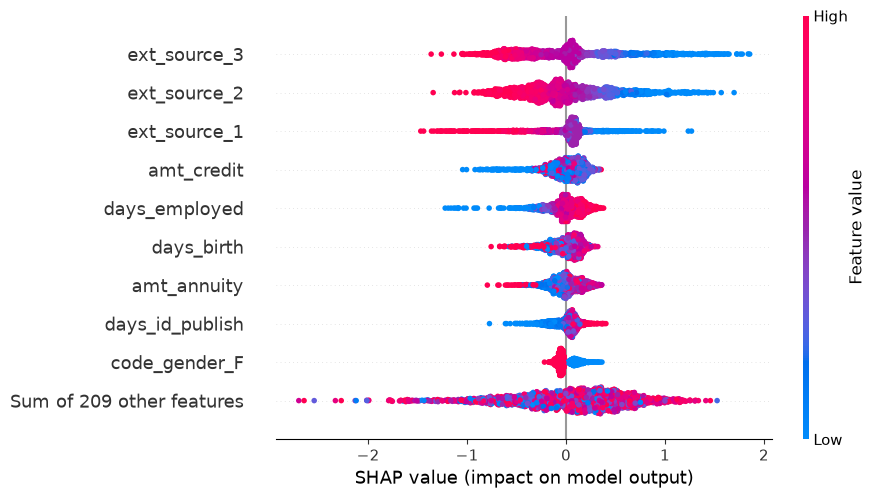

In [10]:
# Sample the test set for faster SHAP computation
X_sample = X_test_others.sample(n=2000, random_state=42)

# Create the explainer
explainer = shap.TreeExplainer(best_lightgbm)

# Compute SHAP values
shap_values = explainer(X_sample)

# Global feature importance
shap.plots.beeswarm(shap_values)

### Train on SMOTE data

In [8]:
param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "num_leaves": [15, 31, 63],
    "max_depth": [5, 10, 20],
    "min_child_samples": [5, 10, 20, 30, 50],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1, 5],
    "reg_lambda": [0, 0.1, 1, 5]
}

In [13]:
import re

# Save original names if you want to refer back to them later
original_columns = X_train_others.columns.tolist()

# Create a mapping from old to new names
new_columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', col)
    for col in X_train_others.columns
]

# Rename both datasets identically
X_train_others_smote = X_train_others_smote.copy()
X_test_others_smote = X_test_others.copy()

X_train_others_smote.columns = new_columns
X_test_others_smote.columns = new_columns

In [15]:
lgbm_sm = LGBMClassifier(
    objective="binary",
    random_state=42,
    n_jobs=1,
    verbosity=-1
)

random_lgbm_sm = RandomizedSearchCV(
    estimator=lgbm_sm,
    param_distributions=param_dist,
    n_iter=75,
    scoring="f1",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_lgbm_sm.fit(X_train_others_smote, y_train_others_smote)

best_lightgbm_sm = random_lgbm_sm.best_estimator_

print("Best LightGBM Parameters:")
print(random_lgbm_sm.best_params_)

print('\nBest LightGBM F1 Score:')
print(random_lgbm_sm.best_score_)

Fitting 3 folds for each of 75 candidates, totalling 225 fits


c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_label.py:103: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


Best LightGBM Parameters:
{'subsample': 0.6, 'reg_lambda': 0.1, 'reg_alpha': 0, 'num_leaves': 63, 'n_estimators': 200, 'min_child_samples': 20, 'max_depth': 20, 'learning_rate': 0.03, 'colsample_bytree': 0.6}

Best LightGBM F1 Score:
0.948300888928714


In [14]:
X_train_others_smote.shape

(361836, 218)

In [6]:
y_train_others_smote.shape

(361836, 1)

Save the model

In [16]:
joblib.dump(best_lightgbm_sm, 'models/best_lightgbm_sm.pkl')

['models/best_lightgbm_sm.pkl']

Find the best threshold

In [17]:
val_prob_sm = best_lightgbm_sm.predict_proba(X_val_others)[:, 1]

thresholds = np.arange(0.05, 1.00, 0.05)

best_threshold_sm = 0.5
best_f1_sm = 0

for t in thresholds:
    pred_sm = (val_prob_sm >= t).astype(int)
    score_sm = f1_score(y_val_others, pred_sm)

    if score_sm > best_f1_sm:
        best_f1_sm = score_sm
        best_threshold_sm = t

print("Best threshold:", best_threshold_sm)
print("Validation F1:", best_f1_sm)

Best threshold: 0.15000000000000002
Validation F1: 0.29423317264774146


Test on the test dataset

In [18]:
test_prob_sm = best_lightgbm_sm.predict_proba(X_test_others)[:, 1]

test_pred_sm = (test_prob_sm >= best_threshold_sm).astype(int)

print(classification_report(y_test_others, test_pred_sm))

              precision    recall  f1-score   support

           0       0.95      0.88      0.91     56538
           1       0.24      0.42      0.30      4965

    accuracy                           0.84     61503
   macro avg       0.59      0.65      0.61     61503
weighted avg       0.89      0.84      0.86     61503



Shapley values 

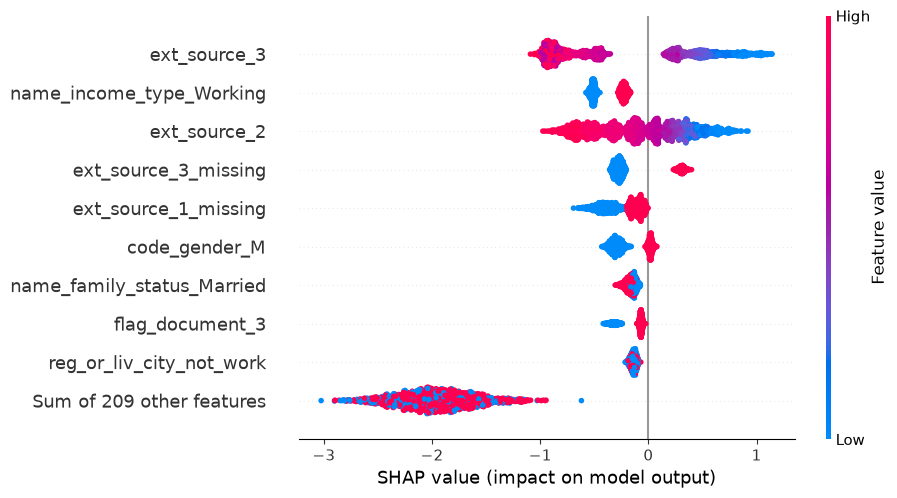

In [20]:
# Sample the test set for faster SHAP computation
X_sample = X_test_others.sample(n=2000, random_state=42)

# Create the explainer
explainer_sm = shap.TreeExplainer(best_lightgbm_sm)

# Compute SHAP values
shap_values_sm = explainer_sm(X_sample)

# Global feature importance
shap.plots.beeswarm(shap_values_sm)